Import Libraries

In [9]:
import os
import librosa
import librosa.display
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Feature Extraction Function

In [10]:
def analyze_audio_extended(path, bins=30):
    y, sr = librosa.load(path, sr=None)
    S = np.abs(librosa.stft(y))
    
    # Low-frequency energy (first N bins)
    low_energy = S[:bins, :].mean()
    
    # Additional features
    centroid = librosa.feature.spectral_centroid(y=y, sr=sr).mean()
    bandwidth = librosa.feature.spectral_bandwidth(y=y, sr=sr).mean()
    rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr).mean()
    zcr = librosa.feature.zero_crossing_rate(y).mean()
    
    return {
        "low_energy": low_energy,
        "centroid": centroid,
        "bandwidth": bandwidth,
        "rolloff": rolloff,
        "zcr": zcr
    }

Analyze All Audio Files

In [11]:
def analyze_all_audio(directory="data/audio_raw"):
    results = []

    for fname in os.listdir(directory):
        if fname.endswith(".wav"):
            path = os.path.join(directory, fname)
            features = analyze_audio_extended(path)
            features["song"] = os.path.splitext(fname)[0]
            results.append(features)

    df = pd.DataFrame(results)
    df = df[["song", "low_energy", "centroid", "bandwidth", "rolloff", "zcr"]]
    return df

Visualize Low Frequency Energy

In [12]:
def plot_low_energy_bar(df):
    df_sorted = df.sort_values(by="low_energy", ascending=False)

    plt.figure(figsize=(10, 5))
    plt.barh(df_sorted["song"], df_sorted["low_energy"], color="lightblue")
    plt.xlabel("Low-Frequency Energy")
    plt.title("Bass Energy per Song")
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

Run Analysis & Visualization

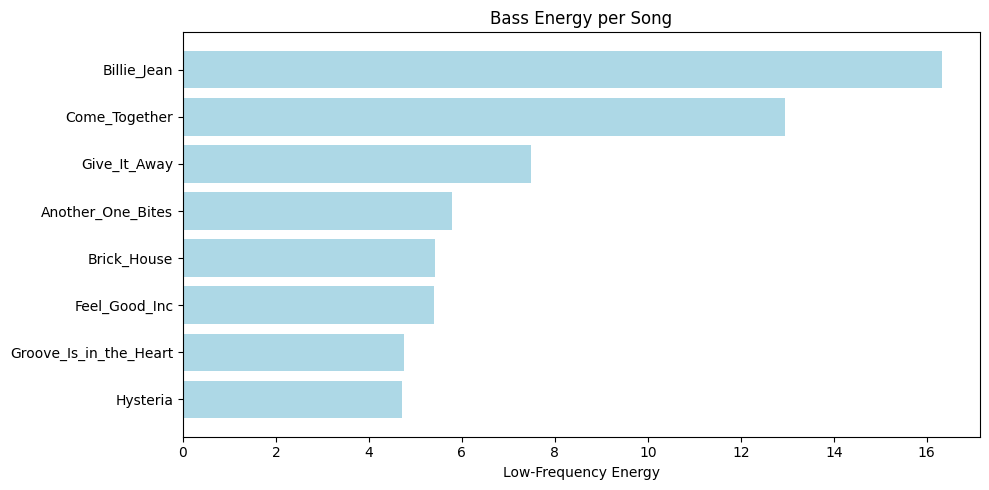

,song,low_energy,centroid,bandwidth,rolloff,zcr
0,Another_One_Bites,5.795576,2338.040110,2510.636920,4489.180101,0.053766
1,Billie_Jean,16.329254,4174.449540,4377.343054,8791.013724,0.082006
2,Brick_House,5.424428,3174.546993,3207.440381,6228.437873,0.080956
3,Come_Together,12.941783,2291.192111,2967.473597,4630.908982,0.036510
4,Feel_Good_Inc,5.401340,3078.381065,3430.487433,6049.473829,0.068465
5,Give_It_Away,7.477998,5384.743474,5377.547774,12144.645057,0.115114
6,Groove_Is_in_the_Heart,4.748541,2853.849268,2964.828739,5814.116557,0.067835
7,Hysteria,4.720984,2822.664995,2966.396709,5695.272655,0.071430


In [13]:
df_features = analyze_all_audio()
plot_low_energy_bar(df_features)
df_features